# Stage 7 — Earth model-input construction

_Pipeline stage 7 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## 5-class confluence patches for the CNN

The CNN sees each confluence as a **128×128, 5-class** raster
(BACKGROUND / BRANCH_A / BRANCH_B / OTHER_STREAMS / CONFLUENCE_MARKER), drawn directly
into the final grid (the frozen rasterizer contract). This encodes the *shape* of the
meeting — branch geometry and local stream context — that the 5 scalar features
cannot. We inspect manifest health, the within-patch class budget, and a real gallery.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · Manifest status + invalid-patch reasons

In [2]:
from channel_heads.rasterization.schema import (BACKGROUND, BRANCH_A, BRANCH_B,
                                                  OTHER_STREAMS, CONFLUENCE_MARKER, NUM_CLASSES)
print('NUM_CLASSES =', NUM_CLASSES)
for r in REGIMES_:
    p = RESULTS_DIR / f'raster_manifest_{r}.csv'
    if not p.exists(): continue
    d = pd.read_csv(p)
    ok = int((d.raster_status == 'ok').sum()) if 'raster_status' in d else len(d)
    print(f'{r}: {len(d)} rows | {ok} ok | {len(d)-ok} invalid')
man = pd.read_csv(RESULTS_DIR / 'raster_manifest_regA.csv')
if 'raster_qa_reason' in man.columns:
    bad = man[man.raster_status != 'ok']['raster_qa_reason'].value_counts().head(8)
    print('\ntop invalid reasons (regA):'); print(bad.to_string() if len(bad) else '  (none)')

NUM_CLASSES = 5
regA: 22292 rows | 20403 ok | 1889 invalid
regB: 16945 rows | 15480 ok | 1465 invalid


regC: 33754 rows | 30981 ok | 2773 invalid


### 2 · Within-patch class budget (how much of each class a patch carries)

In [3]:
man_ok = man[man.raster_path.notna()]
if 'raster_status' in man_ok: man_ok = man_ok[man_ok.raster_status == 'ok']
counts = {c: [] for c in range(NUM_CLASSES)}
for p in man_ok.raster_path.head(300):
    a = np.load(_abs(p)); lab = a.argmax(0) if a.ndim == 3 else a
    u, n = np.unique(lab, return_counts=True); frac = dict(zip(u, n / lab.size))
    for c in range(NUM_CLASSES): counts[c].append(frac.get(c, 0.0))
names = ['BACKGROUND','BRANCH_A','BRANCH_B','OTHER_STREAMS','CONFLUENCE_MARKER']
pd.DataFrame({'class': names, 'mean_pixel_fraction': [round(np.mean(counts[c]), 4) for c in range(NUM_CLASSES)]})

,class,mean_pixel_fraction
0,BACKGROUND,0.9723
1,BRANCH_A,0.0045
2,BRANCH_B,0.0084
3,OTHER_STREAMS,0.0147
4,CONFLUENCE_MARKER,0.0001


### 3 · A gallery of real 5-class patches

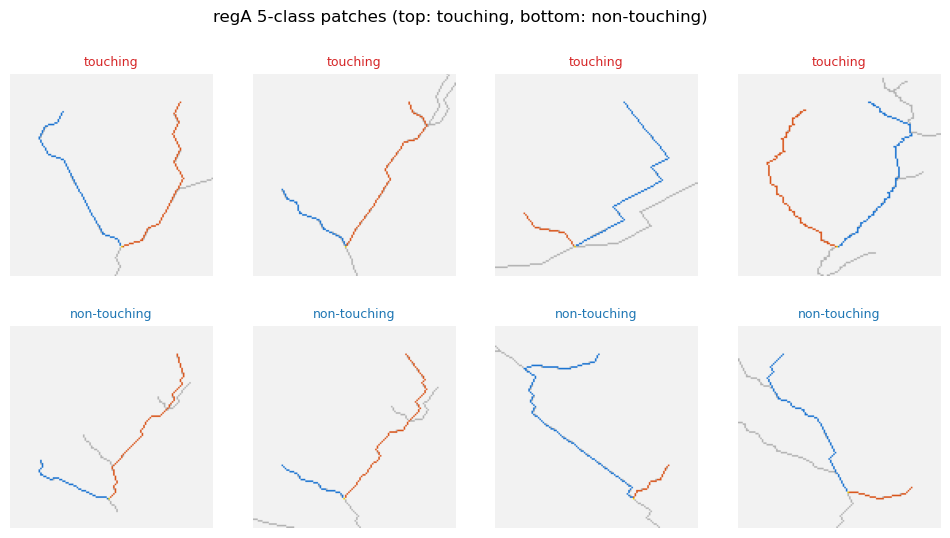

In [4]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap([[0.95,0.95,0.95],[0.85,0.33,0.10],[0.10,0.45,0.82],[0.70,0.70,0.70],[0.90,0.80,0.0]])
def lab(p):
    a = np.load(_abs(p)); return a.argmax(0) if a.ndim == 3 else a
samp = pd.concat([man_ok[man_ok.y==1].head(4), man_ok[man_ok.y==0].head(4)])
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.ravel(), samp.iterrows()):
    ax.imshow(lab(row.raster_path), cmap=cmap, vmin=0, vmax=4)
    c = '#d62728' if row.y == 1 else '#1f77b4'
    ax.set_title('touching' if row.y == 1 else 'non-touching', color=c, fontsize=9); ax.axis('off')
plt.suptitle('regA 5-class patches (top: touching, bottom: non-touching)'); plt.show()

**Takeaway.** Patches are dominated by BACKGROUND (most of the 128² grid is empty),
with thin BRANCH_A/B traces meeting at the CONFLUENCE_MARKER — a sparse, shape-centric
encoding. A small fraction of pairs are flagged invalid (degenerate geometry) and
excluded. This 5-class contract is **frozen**: Mars patches (Stage 10) must match it
exactly so the Earth-trained CNN applies without retraining.